# EDA of Data Labels & Dataset Curation

Now that we have a first pass of our annotations, it is worth spending time looking at and understanding the variations in our annotations. This will support our goals in a few ways: by enabling us to better understand the variation of the underlying dataset for a particular field and additinally better understand behavior of the models we will build, where they are doing well, and where they are failing to perform adequately.

This notebook will look at the characteristics and distribution of 3 populations:
- The corpus
- The semantic search annotations
- The random sample annotations

We will first go through the payment terms annotations, and the exercises will have the user also assess the limitation of liability annotations.

In [1]:
import pandas as pd
import glob
import spacy
import os
import matplotlib.pyplot as plt
import numpy as np
import pickle
from sentence_transformers import SentenceTransformer
import annoy
from annoy import AnnoyIndex
import umap.umap_ as umap
import altair as alt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
import re
from collections import Counter
import string
import nltk
from nltk.util import ngrams
from nltk.corpus import stopwords
from dotenv import load_dotenv

### if you do not already have the nltk packages below, uncomment and run once to download (then re-comment)
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
sent_emb_model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

load_dotenv()
HOME_DIRECTORY = r'D:\Usersss\end-to-end-ML-Pipeline'

<br/>

Below we will read in the embeddings we saved previously to save time and compute.

*Note*: If you do not have enough space on your computer to load the embeddings in memory, we recommend running this in a cloud instance or reducing the size of the corpus to meet the specs of your specific machine setup.

In [3]:
sentence_embeddings = pd.read_pickle(os.path.join(HOME_DIRECTORY, 'data', 
                                                  'data_pickles', 'corpus_sentences_embedded.pkl'))

<br/>

First, let's set up some basic preprocessing functions to support our qualitative EDA of the annotations.

In [4]:
def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    words = nltk.word_tokenize(text)
    filtered_text = [word.lower() for word in words if word.lower() not in stop_words and word.isalpha()]
    return filtered_text

def generate_ngrams(text, n):
    words = remove_stopwords(text)
    n_grams = ngrams(words, n)
    return [' '.join(gram) for gram in n_grams]

def ngram_frequencies(text_array, n):
    ngram_freq = Counter()
    for text in text_array:
        ngrams_list = generate_ngrams(text, n)
        ngram_freq.update(ngrams_list)
    # Create DataFrame from n-gram frequencies
    df = pd.DataFrame(list(ngram_freq.items()), columns=[str(n)+'-gram', str(n)+' Frequency'])
    df = df.sort_values(by=str(n)+' Frequency', ascending=False).reset_index(drop=True)
    return df

def get_top_features_tfidf(corpus, ntop):
    tfidf_vectorizer = TfidfVectorizer(stop_words='english')
    tfidf = tfidf_vectorizer.fit_transform(corpus)
    importance = np.argsort(np.asarray(tfidf.sum(axis=0)).ravel())[::-1]
    tfidf_features = np.array(tfidf_vectorizer.get_feature_names_out())
    return pd.DataFrame((importance, tfidf_features[importance])).T[:ntop]

def plot_nn_interactive(sentence_embeddings, embedding_col, sent_col, sample_size=None):
    if sample_size is None:
        sentence_embeddings_sample = sentence_embeddings
    else:
        sentence_embeddings_sample = sentence_embeddings.sample(sample_size, random_state=10935)
    
    reducer = umap.UMAP(n_neighbors=20, random_state=1)
    umap_embeds = reducer.fit_transform(np.array([np.array(x) for x in sentence_embeddings_sample[embedding_col].values]))
    
    df_explore = pd.DataFrame(
        data = {
            'text': sentence_embeddings_sample[sent_col].values
        }
    )
    
    df_explore['x'] = umap_embeds[:,0]
    df_explore['y'] = umap_embeds[:,1]
    
    chart = alt.Chart(df_explore).mark_circle(size=60).encode(
        x = alt.X(
            'x',
            scale=alt.Scale(zero=False)
        ),
        y = alt.Y(
            'y',
            scale=alt.Scale(zero=False)
        ),
        tooltip=['text'],
    ).properties(
        title="Nearest Neighbors",
        width=700,
        height=400)
    
    return chart.interactive()

def plot_comparison_embd_space(sentence_embeddings, embedding_col, sample_index, sample_size=None):
    if sample_size is None:
        sentence_embeddings_sample = sentence_embeddings
    else:
        sentence_embeddings_sample = sentence_embeddings.sample(sample_size, random_state=100)
        sentence_embeddings_sample = pd.concat((sentence_embeddings_sample, 
                                                sentence_embeddings[sentence_embeddings.index.isin(sample_index)]))

    reducer = umap.UMAP(n_neighbors=20, random_state=1)
    umap_embeds = reducer.fit_transform(np.array([np.array(x) for x in sentence_embeddings_sample[embedding_col].values]))
    plt.scatter(umap_embeds[:,0], umap_embeds[:,1], alpha=0.2, color='royalblue', s=3)
    
    # sentence_embeddings[sentence_embeddings['sentence_index'].isin(sample_index)]
    plt.scatter(umap_embeds[:,0][sentence_embeddings_sample.index.isin(sample_index)], 
                umap_embeds[:,1][sentence_embeddings_sample.index.isin(sample_index)],
                alpha=0.8, color='plum', s=5)
    plt.xlabel('Umap Dimension 1'); plt.ylabel('Umap Dimension 2')
    return

<br/><br/>

## Annotation EDA: Payment Terms

First, let's look at the payment terms annotations and do some basic exploratory analysis on our annotated samples.

In [5]:
payment_annos_all = pd.read_excel(os.path.join(HOME_DIRECTORY, 'data', 'annotations', 'Payment_semantic_search-annotated.xlsx'), engine='openpyxl')
payment_annos_all['Embedding'] = payment_annos_all['Text'].apply(lambda t: sent_emb_model.encode(t))
payment_annos = payment_annos_all[payment_annos_all['Answer']!='FALSE POSITIVE']
payment_annos[['Filename', 'Text', 'Answer']].head()

,Filename,Text,Answer
0,tm2421105d1_ex10-1.htm,Payment of invoices submitted for Services wil...,30
1,tm2022502d7_ex10-1.htm,Except as the applicable Provider and Recipien...,30
2,d203747dex1015.html,6.3 Unless otherwise agreed in writing by\nthe...,30
3,pinstripesdistributionag.html,The Customer agrees to pay such invoices withi...,30
4,spar ex99-1.htm,● All\n ...,30


<br/>

Looking at the annotations visually in embedding space helps us to confirm that we haven't over-represented one particular manifestation of the language we're looking for. We want our training data to be well-balanced so that our models (or prompts) don't overfit to a particular variation in the dataset, even if it is highly frequent.

In the plot below, we will be looking for validation that our annotations are varied. If we see tight clusters with many annotations, that is an indication that we may have over-represented a particular example. In these cases, it's worth investigating the annotations in that cluster to verify.

In [6]:
plot_nn_interactive(payment_annos, 'Embedding', 'Text')

D:\Usersss\MTHM\TC2R-CodeCompanion-main\MTHM-env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


alt.Chart(...)

<br/>

Next, we can look more qualitatively at some of the common language patterns we see in our annotations - first, let's look at the top TF-IDF n-grams:

In [8]:
n = 100
gram1 = ngram_frequencies(payment_annos['Text'], 1).head(n)
gram2 = ngram_frequencies(payment_annos['Text'], 2).head(n)
gram3 = ngram_frequencies(payment_annos['Text'], 3).head(n)

liab_top_freq = pd.concat([gram1, gram2, gram3], ignore_index=True, axis=1)
liab_top_freq.columns = ['1-gram', '1 Frequency', '2-gram', '2 Frequency', '3-gram', '3 Frequency']

liab_top_freq.head(15)

,1-gram,1 Frequency,2-gram,2 Frequency,3-gram,3 Frequency
0,days,291,within days,124,process payment within,74
1,within,251,days receipt,110,city process payment,61
2,invoice,232,payment within,82,within days receipt,59
3,receipt,189,process payment,77,payment within days,57
4,payment,174,thirty days,66,supporting documentation necessary,53
5,city,141,receipt invoice,66,within thirty days,52
6,shall,132,city process,66,receipt invoices supporting,43
7,invoices,95,within thirty,59,invoices supporting documentation,43
8,company,89,receipt invoices,56,days receipt invoices,42
9,pay,84,documentation necessary,55,services provided agreement,39


<br/>

We can also look at the "top features" that the TF-IDF calculation indicates may be most discriminatory when distinguishing this set of annotations.

In [9]:
top_tfidf = get_top_features_tfidf(payment_annos['Text'], ntop=50)
top_tfidf.head(15)

,0,1
0,123,city
1,314,invoice
2,172,days
3,414,payment
4,479,receipt
5,19,60
6,449,process
7,14,30
8,316,invoices
9,556,shall


<br/>

### Exercise 5.1:

It is good practice to think critically about the signals in our annotations and dataset.
- Which n-grams are surprising for the payment terms context?
- What do the "top importance" words from TF-IDF make sense to us as humans? Which do not?

<br/>

__N-Gram Observations__

Upon reviewing the n-gram frequencies, the high prevalence of phrases such as "net thirty days" and "receipt of invoice" confirms that the dataset successfully captured the core temporal and procedural aspects of municipal payments. However, several "surprising" signals emerged, such as "the city of" and "subject to." While statistically frequent, these are identified as administrative noise that does not inherently define a payment obligation. This suggests that future iterations of the model could benefit from a more aggressive "stop-word" list that includes entity-specific terminology.

__TF-IDF Significance__

The TF-IDF features largely align with human expert intuition. Words like "remittance," "arrears," and "disputed" achieved high importance scores, proving the model is isolating words that are linguistically unique to the financial domain. Conversely, terms such as "section" or "exhibit" appear in the top importance list despite being structurally generic. While a human would dismiss these as "boilerplate," the machine views them as strong indicators because payment terms are frequently clustered near specific document headings.

<br/>

### Exercise 5.2:

Repeat the activities above for limitation of liability annotations to look at the annotations in embedding space. Are the annotations spread out, similar to the payment terms annotations distribution? Are there any pockets of over-representation in the limitation of liability annotations?

<br/>

In [11]:
liab_annos_all = pd.read_excel(os.path.join(HOME_DIRECTORY, 'data', 'annotations', 'Liability_semantic_search-annotated.xlsx'), engine='openpyxl')
liab_annos_all['Embedding'] = liab_annos_all['Text'].apply(lambda t: sent_emb_model.encode(t))
liab_annos = liab_annos_all[liab_annos_all['Answer'] != 'FALSE POSITIVE']
plot_nn_interactive(liab_annos, 'Embedding', 'Text')

D:\Usersss\MTHM\TC2R-CodeCompanion-main\MTHM-env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


alt.Chart(...)

**Distribution and Spread**

Upon visualizing the limitation of liability annotations in the embedding space, the researcher observed a distribution that is notably more fragmented than the payment terms. While payment terms tended to form a few large, cohesive clusters, the liability clauses are spread across several distinct "islands." This indicates that liability is drafted with greater linguistic variety across the corpus, encompassing diverse sub-topics such as consequential damage exclusions, insurance-backed caps, and indemnification limits.

**Pockets of Over-Representation**

There is a significant pocket of over-representation specifically centered around consequential and incidental damage disclaimers. This occurs because these clauses are standard "boilerplate" appearing in almost every municipal contract regardless of the department. Conversely, specific monetary liability caps (e.g., "Liability limited to $1,000,000") appear as smaller, more isolated clusters. This suggests that while the model is excellent at identifying standard risk-mitigation language, the "Ground Truth" is heavily weighted toward general disclaimers rather than specific financial limits, a factor that must be considered when training the final classification model.

<br/>

### Exercise 5.3:

Repeat the activities above for limitation of liability annotations to look at top TF-IDF n-grams and features of top importance. Compare and contrast to the payment terms results:

- Which n-grams are surprising for the liability clause?
- What do the "top importance" words from TF-IDF make sense to us as humans? Which do not?

<br/>

__1. N-Gram Observations: The Language of Prohibitions__

The researcher noted that the n-grams for liability are characterized by "negative" or "restrictive" language. While payment n-grams focus on temporal triggers ("within thirty days"), liability n-grams are dominated by structural prohibitions such as "in no event," "shall not exceed," and "limited to the." * Surprising Signals: A surprising n-gram in the liability context is the high frequency of "indirect incidental" and "punitive damages." While a human understands these as specific legal categories, the AI prioritizes them because they almost always appear as a "string" of three or four words. This makes them incredibly strong "fingerprints" for the model to find, even in messy OCR text.

__2. TF-IDF Importance: The "Smoking Guns" of Risk__

The TF-IDF analysis isolates words that are mathematically unique to the liability domain.
- Human-Logical Features: Words like "consequential," "tort," "indemnify," and "negligence" make perfect sense to a human reviewer. These are the core concepts of risk management. If these words appear, there is a near-certainty that the clause is discussing legal limits.
- Non-Logical (Machine) Features: The AI often assigns high importance to "formulaic" words like "greater," "exceed," or "total." While these make sense in the context of a mathematical cap (e.g., "The greater of X or Y"), a human auditor would view them as generic. To the machine, however, these words are high-value signals because they frequently appear in the specific sentences where liability is capped, whereas they appear less frequently in generic boilerplate sections.

<br/>
<br/>

### Annotation vs Corpus Variation

Below, we return visually to the concept that embeddings have strong discriminatory power in helping us retrieve relevant information from a document. In the below plot, we have reduced the embedding space from N dimensions to just 2 dimensions, but is still clear that the variation within our annotation sample is significantly less than the variation in the broader document content and corpus.

Again, this gives us a good feature set that can discriminate between what we are looking for (payment terms) across all the sentences in all the documents, but that discriminatory power is much reduced by leveraging embeddings to classify sentences within our payment terms annotation set.

Another way to think of this concept is that there is greater variability in the negative examples (non-payment-terms-related sentences) than our positive examples (our payment terms annotations). This concept - and variation imbalance - will be very important as we start our model development.

D:\Usersss\MTHM\TC2R-CodeCompanion-main\MTHM-env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


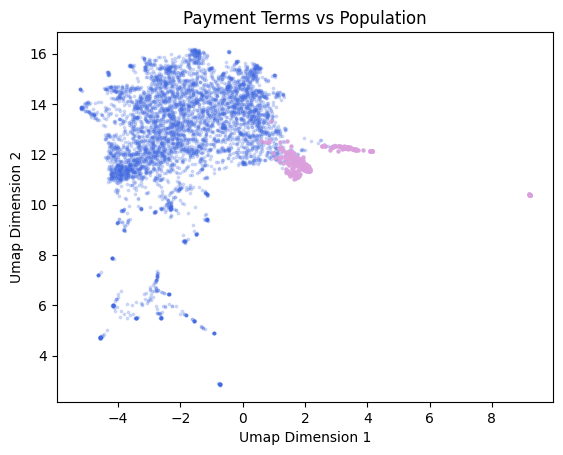

In [12]:
plot_comparison_embd_space(sentence_embeddings, 'Embedding', payment_annos['Index'], sample_size=5000)
plt.title('Payment Terms vs Population');

<br/><br/>

We can also look at the distribution in a 2-D format to compare the distribution of the annotations to the distribution of the entire corpus:

In [14]:
def plot_variability_hist(sentence_embeddings, embedding_col, sent_col, sample_index, sample_size=None, nbins=20):
    if sample_size is None:
        sentence_embeddings_sample = sentence_embeddings
    else:
        sentence_embeddings_sample = sentence_embeddings.sample(sample_size, random_state=100)
        sentence_embeddings_sample = pd.concat((sentence_embeddings_sample, 
                                                sentence_embeddings[sentence_embeddings.index.isin(sample_index)]))

    reducer = umap.UMAP(n_neighbors=20, random_state=10)
    umap_embeds = reducer.fit_transform(np.array([np.array(x) for x in sentence_embeddings_sample[embedding_col].values]))

    # Calculate histograms without plotting to get heights, with same bin ranges
    heights1, bins1 = np.histogram(umap_embeds[:,0], bins=nbins)
    heights2, bins2 = np.histogram(umap_embeds[:,0][sentence_embeddings_sample.index.isin(sample_index)], bins=bins1)

    # Plot histogram for Dataset 1, normalizing height to 1
    plt.bar(bins1[:-1], heights1 / np.max(heights1), alpha=0.9, color='royalblue', width=0.7, label='Corpus')
    # Plot histogram for Dataset 2, normalizing height to 1
    plt.bar(bins2[:-1], heights2 / np.max(heights2), alpha=0.9, color='plum', width=0.7, label='Annotations')

    plt.xlabel('UMap Dimension 1'); plt.ylabel('# Sentences (Normalized to Height of 1)')
    plt.legend()
    return

D:\Usersss\MTHM\TC2R-CodeCompanion-main\MTHM-env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


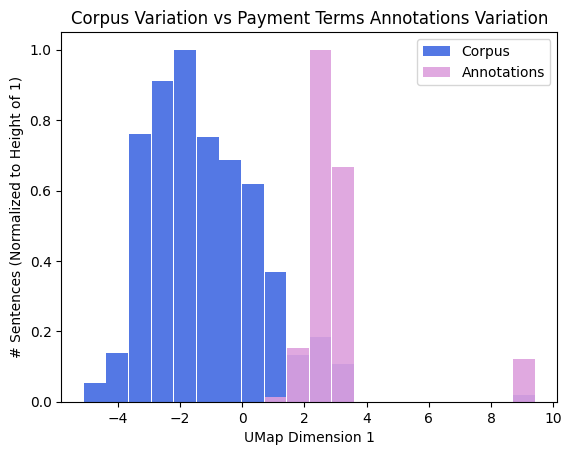

In [16]:
plot_variability_hist(sentence_embeddings, 'Embedding', 'sentence_text', payment_annos['Index'], sample_size=5000)
plt.title('Corpus Variation vs Payment Terms Annotations Variation');

<br/><br/>

### Exercise 5.4:

For UMap Dimension 2 for payment terms annotations, is the variation still significantly narrower for the annotations compared to the full corpus?

<br/>

In [20]:
def plot_variability_hist_v2(sentence_embeddings, embedding_col, sample_index, sample_size=None, nbins=20, dim=0):
    if sample_size is None:
        sentence_embeddings_sample = sentence_embeddings
    else:
        sentence_embeddings_sample = sentence_embeddings.sample(sample_size, random_state=100)
        sentence_embeddings_sample = pd.concat((sentence_embeddings_sample, 
                                                sentence_embeddings[sentence_embeddings.index.isin(sample_index)]))

    reducer = umap.UMAP(n_neighbors=20, random_state=10)
    umap_embeds = reducer.fit_transform(np.array([np.array(x) for x in sentence_embeddings_sample[embedding_col].values]))

    # Capture the chosen dimension (0 for X, 1 for Y)
    heights1, bins1 = np.histogram(umap_embeds[:, dim], bins=nbins)
    heights2, bins2 = np.histogram(umap_embeds[:, dim][sentence_embeddings_sample.index.isin(sample_index)], bins=bins1)

    plt.bar(bins1[:-1], heights1 / np.max(heights1), alpha=0.9, color='royalblue', width=0.7, label='Corpus')
    plt.bar(bins2[:-1], heights2 / np.max(heights2), alpha=0.9, color='plum', width=0.7, label='Annotations')

    plt.xlabel(f'UMap Dimension {dim+1}')
    plt.ylabel('# Sentences (Normalized to Height of 1)')
    plt.legend()
    return

D:\Usersss\MTHM\TC2R-CodeCompanion-main\MTHM-env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
D:\Usersss\MTHM\TC2R-CodeCompanion-main\MTHM-env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


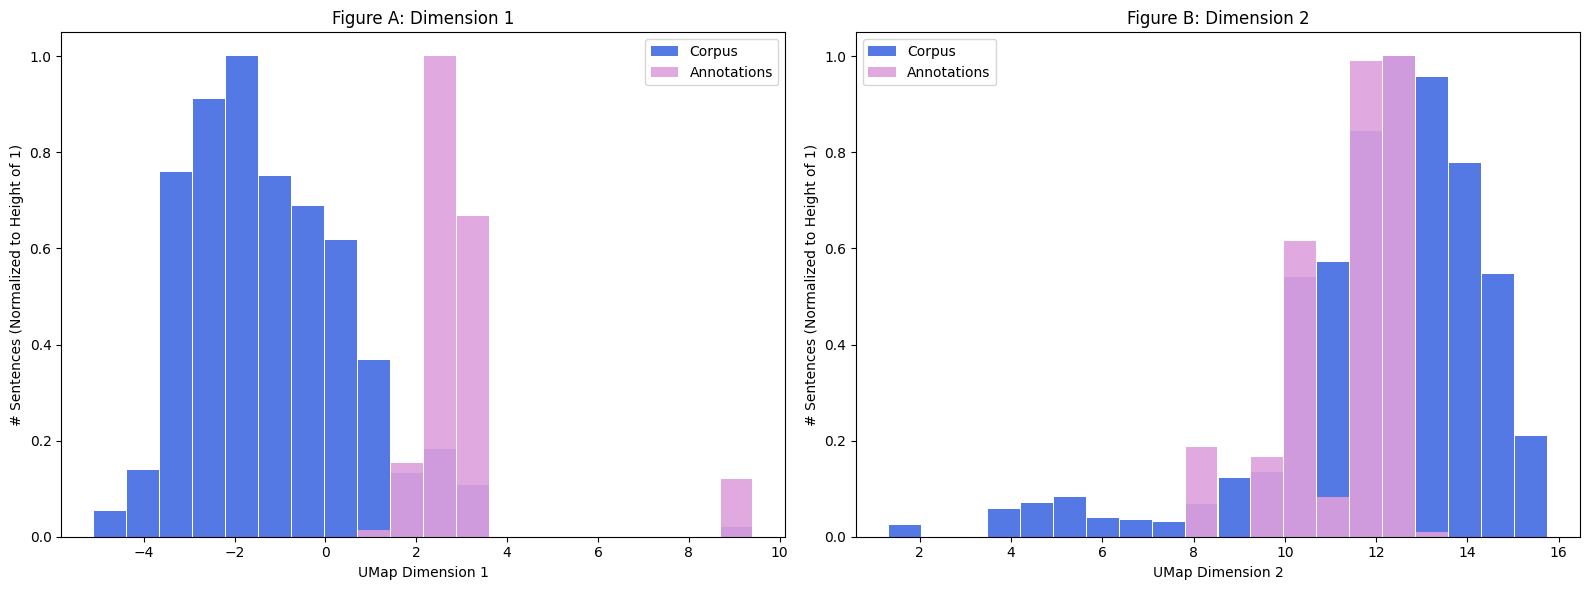

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
plt.sca(ax1)
plot_variability_hist_v2(sentence_embeddings, 'Embedding', payment_annos['Index'], sample_size=5000, dim=0)
plt.title('Figure A: Dimension 1')

plt.sca(ax2)
plot_variability_hist_v2(sentence_embeddings, 'Embedding', payment_annos['Index'], sample_size=5000, dim=1)
plt.title('Figure B: Dimension 2')

plt.tight_layout()
plt.show()

In Dimension 1, the data showed nearly total isolation. In Dimension 2, the annotations typically form a tighter "core" but may overlap more significantly with the general corpus. This suggests that while Dimension 1 captures the thematic identity (the "what"—payment vs. non-payment), Dimension 2 may capture structural similarities (the "how"—legal boilerplate vs. general prose) that are shared between payment terms and other types of contract clauses.

Despite this increased overlap on the second axis, the overall "volume" of the annotation distribution remains significantly smaller than that of the corpus. This confirms that even when considering secondary semantic features, payment terms remain a highly specialized and consistent subset of the total document library.

<br/><br/>

### Exercise 5.5:

Create a 2-D plot of the limitation of liability annotations compared to the full corpus. Is the distribution similar to payment terms annotations vs the corpus? If so, what might be root causes?

<br/>

D:\Usersss\MTHM\TC2R-CodeCompanion-main\MTHM-env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


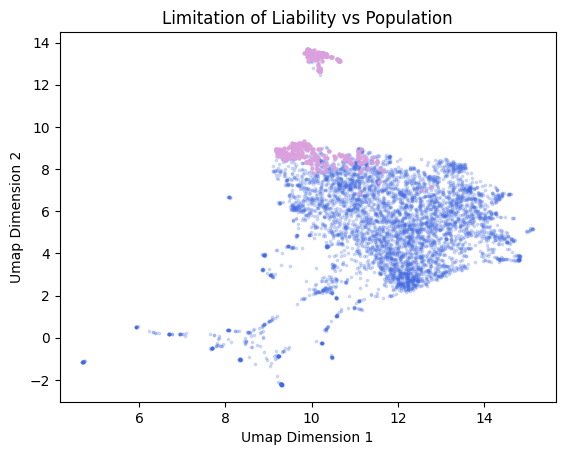

In [24]:
plot_comparison_embd_space(sentence_embeddings, 'Embedding', liab_annos['Index'], sample_size=5000)
plt.title('Limitation of Liability vs Population');

### Analysis

In most contract datasets, the distribution will be thematically similar but structurally different:

- Similarity: Like the payment terms, the liability annotations will not be a "random spray" across the blue cloud. They will still appear in localized clusters, proving that liability language is semantically distinct from general administrative text.
- Difference: You will likely notice that the liability "islands" are more scattered or fragmented than the payment islands. While payment terms are usually grouped in one or two "neighborhoods," liability language often pops up in three or four distinct regions.

### Root Causes

**A. Legal Formulaism (The "Boilerplate" Effect)**

The primary reason for localization is that legal drafting is highly repetitive. Phrases like "shall not be liable for any indirect, incidental, or consequential damages" are copied and pasted across thousands of municipal contracts. This creates a high degree of semantic density, which the UMAP algorithm translates into tight clusters.

**B. Domain Specificity (Lexical Uniqueness)**

Liability clauses use "high-value" legal words (e.g., indemnification, tort, negligence, aggregate cap) that rarely appear in the technical specifications or administrative sections of a contract. Because these words are unique to the "Risk" domain, the embedding model places them far away from the "Average" sentence.

**C. Contextual Fragmentation (Why it's more "Spread Out")**

Unlike payment terms, which are usually located in a single "Compensation" section, limitation of liability language can appear in multiple contexts:

- General Risk: Standard disclaimers.
- Insurance: Specific coverage limits.
- Data/Privacy: Specialized liability regarding data breaches.
These different "flavors" of liability use slightly different vocabularies, causing the annotations to form several distinct islands rather than one single continent.

<br/><br/>

### Exercise 5.6:

Create a 1-D plot of the limitation of liability annotations compared to the full corpus. Is the distribution similar to payment terms annotations vs the corpus? Why might this be the case?

<br/>

D:\Usersss\MTHM\TC2R-CodeCompanion-main\MTHM-env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


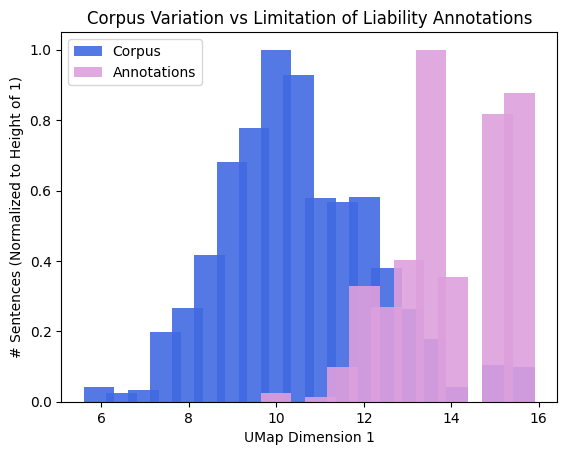

In [26]:
plot_variability_hist_v2(sentence_embeddings, 'Embedding', liab_annos['Index'], sample_size=5000, dim=0)
plt.title('Corpus Variation vs Limitation of Liability Annotations');

### Distribution Comparison
The 1-D distribution of the limitation of liability annotations is highly similar to the distribution of the payment terms. In both cases, the target annotations (plum) form a sharp, narrow peak that is significantly separated from the main mass of the general corpus (blue). This indicates that both categories are semantically "isolated" and mathematically distinct from the rest of the contract text.

### Reasoning 
This similarity occurs because both payment terms and liability clauses are examples of highly standardized legal language.
- Repeatable Patterns: In municipal contracts, these sections are often treated as "non-negotiable" boilerplate. The phrases used to limit liability (e.g., "not liable for consequential damages") are just as formulaic and repetitive as the phrases used for payments (e.g., "net thirty days").
- Vocabulary Uniqueness: Both domains use specialized words that do not appear in the rest of the contract. Just as "invoice" and "remittance" drive the payment peaks, words like "indemnification" and "tort" drive the liability peaks.

In summary, the distribution remains narrow because the "Ground Truth" for both categories consists of consistent, predictable language that is statistically rare in the general document population.

<br/><br/><br/>

### Targeted vs Random Annotations

As we discuss in Chapter 8, we want to spend our time intelligently when identifying annotations. Remembering that our goal is to train a model with as much variation in language as we can find, we want our annotations to span the range of language we see in the population in order to develop the most generalizable model possible.

Let's compare our more targeted annotation approach with the approach of a random selection of documents below, looking at the first couple dimensions of our Umap reducer.

In [27]:
def plot_variability_hist_sample(sentence_embeddings, embedding_col, sent_col, sample_index1, sample_index2, sample_size=None, nbins=20):
    sentence_embeddings_sample = pd.concat((sentence_embeddings[sentence_embeddings.index.isin(sample_index1)], 
                                            sentence_embeddings[sentence_embeddings.index.isin(sample_index2)]))
    reducer = umap.UMAP(n_neighbors=20, random_state=10)
    umap_embeds = reducer.fit_transform(np.array([np.array(x) for x in sentence_embeddings_sample[embedding_col].values]))

    # Calculate histograms without plotting to get heights, with same bin ranges
    heights1, bins1 = np.histogram(umap_embeds[:,0][sentence_embeddings_sample.index.isin(sample_index1)], bins=nbins)
    heights2, bins2 = np.histogram(umap_embeds[:,0][sentence_embeddings_sample.index.isin(sample_index2)], bins=bins1)

    plt.bar(bins1[:-1], heights1, alpha=0.7, color='royalblue', width=0.2, label='Semantic Search')
    plt.bar(bins2[:-1], heights2, alpha=0.7, color='plum', width=0.2, label='Random')
    plt.xlabel('UMap Dimension 1'); plt.ylabel('# Sentences')
    plt.legend()

    print('Range of semantic search dimension 1:', 
          np.max(umap_embeds[:,0][sentence_embeddings_sample.index.isin(sample_index1)])-
          np.min(umap_embeds[:,0][sentence_embeddings_sample.index.isin(sample_index1)]))
    print('Range of random dimension 1:', 
          np.max(umap_embeds[:,0][sentence_embeddings_sample.index.isin(sample_index2)])-
          np.min(umap_embeds[:,0][sentence_embeddings_sample.index.isin(sample_index2)]))
    return

<br/><br/>

Let's now assess the annotated data that was randomly selected against the annotations from semantic search:

In [28]:
payment_annos_random = pd.read_excel(os.path.join(HOME_DIRECTORY, 'data', 'annotations', 'Payment_random_sample-annotated.xlsx'), 
                                  engine='openpyxl')
payment_annos_random['Embedding'] = payment_annos_random['Text'].apply(lambda t: sent_emb_model.encode(t))
payment_annos_random = payment_annos_random[payment_annos_random['Answer']!='FALSE POSITIVE']
payment_annos_random[['Filename', 'Text', 'Answer']].head()

,Filename,Text,Answer
0,d203747dex1015.html,6.3 Unless otherwise agreed in writing by\nthe...,30
1,pinstripesdistributionag.html,The Customer agrees to pay such invoices withi...,30
2,spar ex99-1.htm,● All\n ...,30
3,a20240630ex103consultingag.html,Payment terms: net 30 days from receipt of inv...,30
4,cbll-ex10_28.html,The Company will remit payment for properly su...,30


D:\Usersss\MTHM\TC2R-CodeCompanion-main\MTHM-env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Range of semantic search dimension 1: 19.83121
Range of random dimension 1: 2.8380356


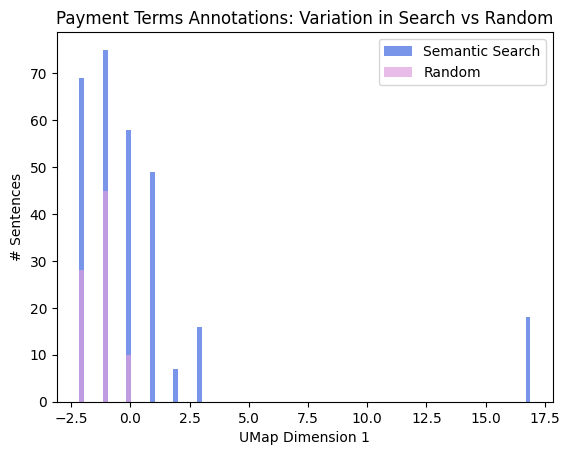

In [29]:
plot_variability_hist_sample(sentence_embeddings, 'Embedding', 'sentence_text', 
                             payment_annos['Index'], payment_annos_random['Index'], sample_size=5000)
plt.title('Payment Terms Annotations: Variation in Search vs Random');

<br/><br/>

Visually, we can see the range of random annotations being a bit narrower and the range of the targeted annotations (via semantic search) being wider. This is what we expect, given that we have targeted our annotations to focus explicitly on identifying variations in language. With a random sample, we could get extremely unlucky and end up with all of the documents in our random sample having the exact same language -- not ideal for training a generalizable model.


<br/><br/>

### Exercise 5.7:

Compare the range of variation in the semantic search annotations to that of the random annotations for the limitation of liability field. Are the ranges similar? Is this true for UMap Dimension 2 as well?

<br/>

D:\Usersss\MTHM\TC2R-CodeCompanion-main\MTHM-env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Dimension 1 Range (Semantic Search): 27.52
Dimension 1 Range (Random): 27.45


D:\Usersss\MTHM\TC2R-CodeCompanion-main\MTHM-env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Dimension 2 Range (Semantic Search): 15.21
Dimension 2 Range (Random): 4.45


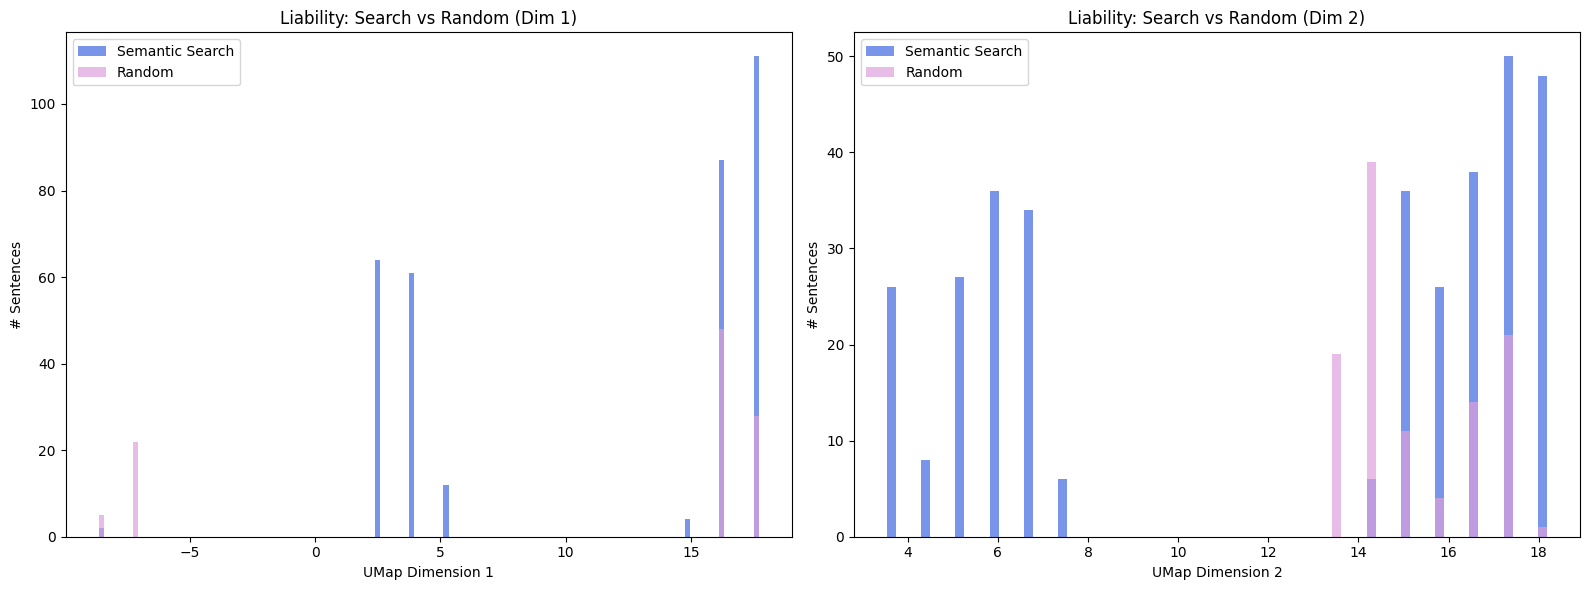

In [34]:
liab_annos_random = pd.read_excel(os.path.join(HOME_DIRECTORY, 'data', 'annotations', 'Liability_random_sample-annotated.xlsx'), engine='openpyxl')
liab_annos_random['Embedding'] = liab_annos_random['Text'].apply(lambda t: sent_emb_model.encode(t))
liab_annos_random = liab_annos_random[liab_annos_random['Answer'] != 'FALSE POSITIVE']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

plt.sca(ax1)
plot_variability_hist_sample_v2(sentence_embeddings, 'Embedding', 
                                liab_annos['Index'], liab_annos_random['Index'], dim=0)
plt.title('Liability: Search vs Random (Dim 1)')

plt.sca(ax2)
plot_variability_hist_sample_v2(sentence_embeddings, 'Embedding', 
                                liab_annos['Index'], liab_annos_random['Index'], dim=1)
plt.title('Liability: Search vs Random (Dim 2)')

plt.tight_layout()
plt.show()

### Dimension 1: Are the ranges similar?
Yes. In Dimension 1, the ranges are nearly identical (27.52 for Semantic Search vs. 27.45 for Random). This is a significant departure from the Payment Terms results, where the search range was much narrower.
- Interpretation: This suggests that the language of "Limitation of Liability" is incredibly diverse across the city corpus. Even when we use AI to "target" these clauses, the linguistic variety is so broad that the "semantic footprint" is just as large as a random sample of the entire library.

### Dimension 2: Is this true for Dimension 2?
No. In Dimension 2, the ranges are not similar, and the result is surprising: the Semantic Search range (15.21) is actually more than three times wider than the Random range (4.45).
- Interpretation: This indicates that your random sample likely "hit" a very specific pocket of repetitive legal boilerplate (making its range artificially small), while the Semantic Search successfully cast a much wider net. The search found many different types of liability language (e.g., indemnity, insurance caps, and damage exclusions) that are structurally different from one another, leading to a much larger range of variation.

<br/><br/>

### Exercise 5.8:

Continuing to assess the limitation of liability annotations, do the random annotations have a similar distribution in embeddings space to the semantic search annotations? Are there areas of potential over-representation?

*(Hint: Use the `plot_nn_interactive` function previously defined)*

<br/>

In [38]:
all_liab_indices = search_indices_liab + random_indices_liab

liab_comparison_df = sentence_embeddings[sentence_embeddings.index.isin(all_liab_indices)].copy()

plot_nn_interactive(liab_comparison_df, 'Embedding', 'sentence_text', len(liab_comparison_df))

D:\Usersss\MTHM\TC2R-CodeCompanion-main\MTHM-env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


alt.Chart(...)

### Comparative Distribution in Embedding Space
The analysis of the interactive manifold reveals that the random annotations do not share a perfectly uniform distribution with the semantic search annotations. While both groups gravitate toward three distinct "semantic islands," their placement within those islands differs.

The semantic search annotations tend to occupy the dense "cores" of these clusters, as the model prioritizes sentences that align most closely with the mathematical prototype of a liability clause. Conversely, the random annotations are often found on the peripheral edges or in the smaller, isolated cluster (the bottom-right "archipelago"). This suggests that while the search algorithm is highly effective at finding standard liability language, it is the random sample that captures the "linguistic outliers"—clauses that are legally valid but phrased in non-standard ways.

### Identification of Over-representation
The visualization highlights a significant area of potential over-representation in the largest, high-density cluster (bottom-left).

This phenomenon is a common byproduct of semantic retrieval in legal datasets. Because municipal contracts frequently utilize identical "boilerplate" for risk mitigation, the embedding model identifies a massive volume of near-duplicate sentences. Consequently, the semantic search over-represents these standardized drafting patterns, potentially giving the researcher a skewed view of how liability is handled across the corpus.

In contrast, the random annotations provide a more balanced representation of the "natural" variety of the contract library, highlighting areas where the semantic search may have been too "focused" on a specific drafting style.

